In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Helper function to display images in the notebook without color issues (OpenCV uses BGR, Matplotlib uses RGB)
def display_image(img_array, size=(10, 10)):
    img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=size)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

print("✅ Setup complete. Ready for inference.")

✅ Setup complete. Ready for inference.


In [2]:
MODEL_PATH = "../models/best.pt"

# Load the model
model = YOLO(MODEL_PATH)

# Let's define your class names so the output makes sense to us
CLASS_NAMES = {
    0: "bin_caged",
    1: "bin_elevated",
    2: "bin_ground",
    3: "trap_object"
}

print(f"✅ Model loaded successfully from {MODEL_PATH}")

✅ Model loaded successfully from ../models/best.pt



image 1/1 /media/ronit/SharedVolume/SignalSprint/ml_backend/notebooks/../test_data/images/img_010.png: 640x640 1 bin_ground, 3.7ms
Speed: 1.5ms preprocess, 3.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
🔍 YOLO Raw Inference Output:


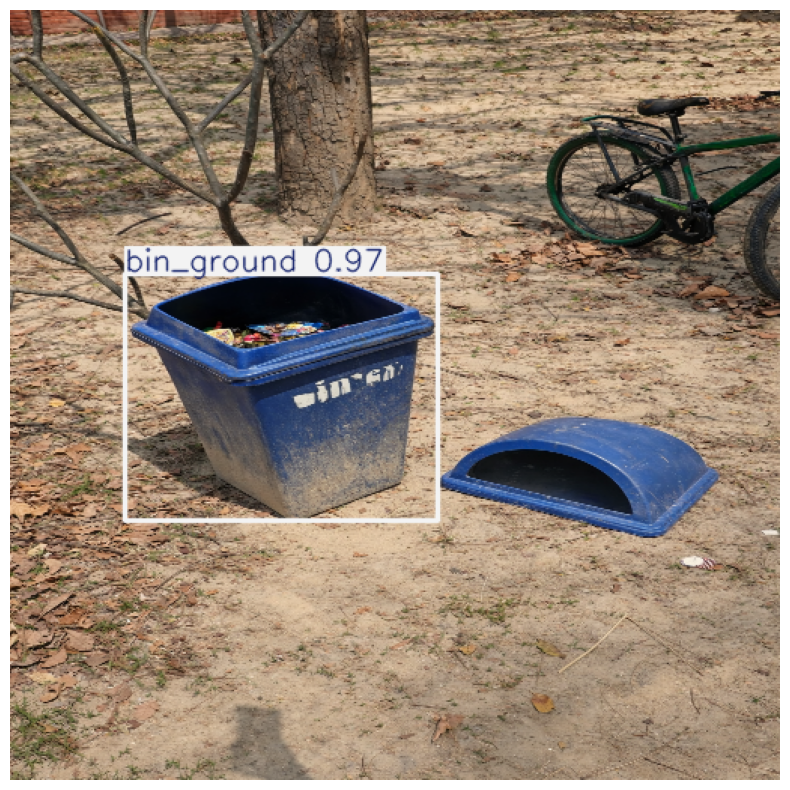

In [21]:
# Point this to an image in your test set
TEST_IMAGE_PATH = "../test_data/images/img_010.png"

# Run inference! (conf=0.5 means we only want predictions it is at least 50% sure about)
results = model.predict(source=TEST_IMAGE_PATH, conf=0.7)

# Extract the first result (since we only passed one image)
result = results[0]

# YOLO has a built-in .plot() function that draws the boxes for you
annotated_img = result.plot()

print("🔍 YOLO Raw Inference Output:")
display_image(annotated_img)

✂️ Processing YOLO detections and extracting 50% Halo crops...

🎯 Extracted Target: bin_ground | Padded Size: 312x246



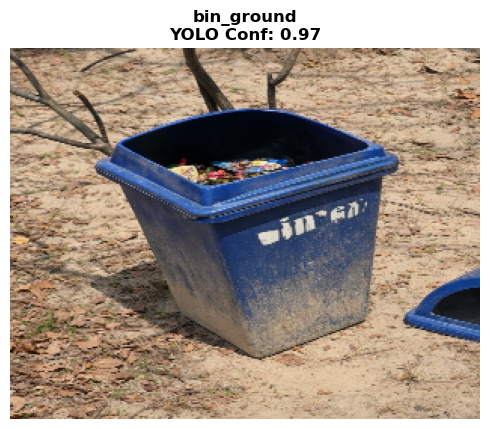

In [23]:
import numpy as np

# YOLO stores the original image array right in the result object (in BGR format)
original_img = result.orig_img 
img_h, img_w = original_img.shape[:2]

# Store our processed, padded crops here to pass to the ViT in Stage 2
vit_inputs = []

print("✂️ Processing YOLO detections and extracting 50% Halo crops...\n")

for box in result.boxes:
    # 1. Extract raw data
    class_id = int(box.cls[0].item())
    confidence = float(box.conf[0].item())
    class_name = CLASS_NAMES[class_id]
    
    # 2. THE SINK LOGIC: Ignore trap objects immediately
    if class_name == "trap_object":
        print(f"🛡️ Ignored a {class_name} (Conf: {confidence:.2f})")
        continue
        
    # 3. Get original bounding box coordinates
    x1, y1, x2, y2 = map(float, box.xyxy[0].tolist())
    bbox_w = x2 - x1
    bbox_h = y2 - y1
    
    # 4. 50% Halo Math (Add 25% padding on all 4 sides)
    pad_x = bbox_w * 0.25
    pad_y = bbox_h * 0.25
    
    # Calculate new bounds and clamp to image edges to prevent crashing
    crop_x1 = int(max(0, x1 - pad_x))
    crop_y1 = int(max(0, y1 - pad_y))
    crop_x2 = int(min(img_w, x2 + pad_x))
    crop_y2 = int(min(img_h, y2 + pad_y))
    
    # 5. Extract the padded image slice
    crop_img = original_img[crop_y1:crop_y2, crop_x1:crop_x2]
    
    if crop_img.size > 0:
        vit_inputs.append({
            "type": class_name,
            "confidence": confidence,
            "crop": crop_img
        })
        print(f"🎯 Extracted Target: {class_name} | Padded Size: {crop_img.shape[1]}x{crop_img.shape[0]}")
    else:
        print(f"⚠️ Warning: Invalid crop calculated for {class_name}")

# 6. Visualize the extracted ViT inputs side-by-side
print("\n" + "="*50)
if vit_inputs:
    # Dynamically scale the plot based on how many bins were found
    fig, axes = plt.subplots(1, len(vit_inputs), figsize=(5 * len(vit_inputs), 5))
    
    # Handle the case where there's only one crop (matplotlib won't return an array of axes)
    if len(vit_inputs) == 1:
        axes = [axes]
        
    for ax, item in zip(axes, vit_inputs):
        # Convert OpenCV's BGR format to Matplotlib's RGB for accurate colors
        img_rgb = cv2.cvtColor(item["crop"], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"{item['type']}\nYOLO Conf: {item['confidence']:.2f}", fontsize=12, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("No valid target bins found in this image. (Only background or traps).")